In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import io
import zipfile
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)


def download_file(url: str, dest: Path, timeout: int = 45):
    if dest.exists():
        return dest
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()
    dest.write_bytes(r.content)
    return dest


def print_source(name: str, mode: str):
    print(f"[{name}] data source: {mode}")

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc
from sklearn.datasets import fetch_openml, make_classification


def load_fraud_data():
    local_csv = DATA_DIR / "creditcard.csv"
    if local_csv.exists():
        df = pd.read_csv(local_csv)
        if "Class" in df.columns:
            print_source("Fraud", "local csv")
            return df

    try:
        om = fetch_openml(name="creditcard", version=1, as_frame=True)
        df = om.frame.copy()
        if "Class" not in df.columns and om.target is not None:
            df["Class"] = om.target
        df["Class"] = pd.to_numeric(df["Class"], errors="coerce").fillna(0).astype(int)
        print_source("Fraud", "downloaded OpenML creditcard")
        return df
    except Exception as e:
        print("Download failed, using synthetic fallback:", e)

    X, y = make_classification(
        n_samples=15000,
        n_features=30,
        n_informative=12,
        n_redundant=8,
        weights=[0.995, 0.005],
        random_state=42,
    )
    cols = [f"V{i}" for i in range(1, X.shape[1] + 1)]
    df = pd.DataFrame(X, columns=cols)
    df["Class"] = y.astype(int)
    print_source("Fraud", "synthetic fallback")
    return df


df = load_fraud_data()
print("Shape:", df.shape)
print(df["Class"].value_counts(normalize=True))

[Fraud] data source: local csv
Shape: (284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


In [3]:
X = df.drop(columns=["Class"])
y = pd.to_numeric(df["Class"], errors="coerce").fillna(0).astype(int)

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
preprocessor = ColumnTransformer([("num", StandardScaler(), num_cols)], remainder="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=42)),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
precision, recall, _ = precision_recall_curve(y_test, y_proba)
print("PR-AUC:", round(auc(recall, precision), 4))

              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962

ROC-AUC: 0.9721
PR-AUC: 0.7639


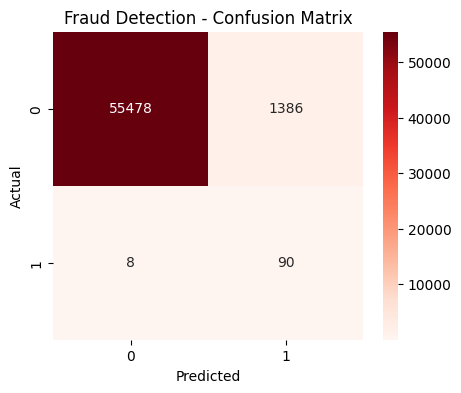

In [4]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
plt.title("Fraud Detection - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()